In [14]:
import numpy as np 
import matplotlib.pyplot as plt
import calc_op_em as coe
import h5py
from tqdm import tqdm
from scipy.interpolate import RegularGridInterpolator as rgi

In [4]:
cube = h5py.File('/dat/milic/SUSI_modeling/extended_off_limb_cube_paper_angle_80.h5','r')

In [10]:
task_end = 1
task_start = 0    
sl = slice(task_start, task_end) # this is a slice object, allowing us to access the specific thingy
#print (sl)
data = {}
data['taskGrainSize'] = task_end - task_start

#print (data['z']/1E3)
data['Temperature'] = cube['Temperature'][sl,:,:]
data['Pressure'] =          cube['Pressure'][sl,:,:]
data['Electron_density'] = cube['Electron_density'][sl,:,:]
data['LOS_velocity'] =        cube['LOS_velocity'][sl,:,:]
data['Population_lower_level'] = cube['Population_lower_level'][sl,:,:]
data['Population_upper_level'] = cube['Population_upper_level'][sl,:,:]


In [ ]:
Temperature = data['Temperature'].astype(float)
Pressure = data['Pressure'].astype(float)
Electron_density = data['Electron_density'].astype(float)
LOS_velocity = data['LOS_velocity'].astype(float)
lower_level_population = data['Population_lower_level'].astype(float)
upper_level_population = data['Population_upper_level'].astype(float)
task_size = data['taskGrainSize']
wave = np.linspace(392.8,394.8,1001)
            
slit_height = Temperature.shape[2]
            
I = np.zeros([task_size, slit_height, len(wave)])
            
i=0              
param_slice = {
    'Temperature': Temperature[i,:,:],
    'Pressure': Pressure[i,:,:],
    'Electron_density': Electron_density[i,:,:],
    'LOS_velocity': LOS_velocity[i,:,:],
    'Population_lower_level': lower_level_population[i,:,:],
    'Population_upper_level': upper_level_population[i,:,:]
}

In [12]:
def create_curved_grid(z_index):
    
    # Meant for testing, but we can also just call it from create ray and then interpolate the slice to get the parameters at each point.
    N_steps = 10001
    
    delta_los = 24.0
    delta_z = 20.0  
    
    s = (np.arange(N_steps) - N_steps // 2) * delta_los # km    
    R_at_the_tangent = 696.0E3 + z_index * delta_z # km
    
    angle = np.arctan(s / R_at_the_tangent)
    y = R_at_the_tangent * angle
    z = z_index * delta_z + np.sqrt(s**2 + R_at_the_tangent**2) - R_at_the_tangent
    
    return s, y, z

def create_ray(slice, z_index):
    
    param_ray = 0
    
    # We need to create a grid of y, z values that traverses as it travels in the spherical geometry 
    # Then we bi-linearly interpolate where we can, and where we fall out - we just set zeros (or we don't even need anything)
    
    s,y,z = create_curved_grid(z_index)
    
    NY = slice['Temperature'].shape[0]
    NZ = slice['Temperature'].shape[1]
    
    delta_los = 24.0
    delta_z = 20.0
    
    # Then we just interpolate the slice to get the parameters at each point.
    y_slice = (np.arange(NY) - NY // 2) * delta_los
    z_slice = (np.arange(NZ)) * delta_z
    
    # Let's use scipy's regular grid interpolatetor for this
    
    interpolator = rgi((y_slice, z_slice), slice['Temperature'], bounds_error=False, fill_value=0.0)
    T_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Pressure'], bounds_error=False, fill_value=0.0)
    P_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Electron_density'], bounds_error=False, fill_value=0.0)
    Ne_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['LOS_velocity'], bounds_error=False, fill_value=0.0)
    V_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Population_lower_level'], bounds_error=False, fill_value=0.0)
    PopL_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Population_upper_level'], bounds_error=False, fill_value=0.0)
    PopU_interpolated = interpolator((y, z))
    
    param_ray = {
        'Temperature': T_interpolated,
        'Pressure': P_interpolated,
        'Electron_density': Ne_interpolated,
        'LOS_velocity': V_interpolated,
        'Population_lower_level': PopL_interpolated,
        'Population_upper_level': PopU_interpolated
    }
    
    return param_ray

In [19]:
myray = create_ray(param_slice, 300)

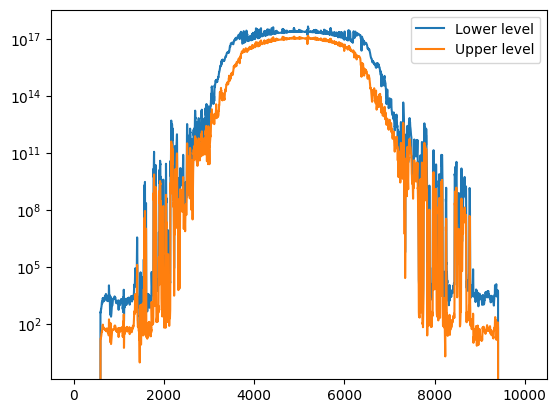

In [18]:
plt.semilogy(myray['Population_lower_level'], label='Lower level')
plt.semilogy(myray['Population_upper_level'], label='Upper level')
plt.legend()